In [64]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [65]:
# Generate a synthetic dataset that can overfit
X, y = make_classification(n_samples=5000, n_features=30, n_classes=2, n_informative=2, n_redundant=20, random_state=42)

In [66]:
# Split the data into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [67]:
# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [68]:
# Build the model

# Create a sequential model with 3 dense layers
# layer 1: 128 units, activation relu
# layer 2: 64 units, activation relu
# layer 3: 1 units, activation sigmoid

model = Sequential ([

     Dense(128, activation='relu'),
     Dense(64, activation='relu'),
     Dense(1, activation='sigmoid')
])

print (model)

In [69]:
# Compile the model

# compile the model with optimizer: adam, loss function: 'binary_crossentropy', and metrics: accuracy -> metrics=['accuracy']

optimizer = 'adam'
loss = 'binary_crossentropy'
metrics=['accuracy']

model.compile(optimizer='adam', 
              loss='binary_crossentropy',  
              metrics=['accuracy'])


In [70]:
# Train the model

# Train the model with 200 epochs, batch_size=32, and use the validation data you created 
# in the validation_data parameter -> validation_data=(X_val,y_val). Save the history.

history = model.fit(X_train,y_train, epochs=200, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/200
94/94 [==============================] - 1s 6ms/step - loss: 0.3435 - accuracy: 0.8617 - val_loss: 0.3119 - val_accuracy: 0.8670
Epoch 2/200
94/94 [==============================] - 0s 3ms/step - loss: 0.3044 - accuracy: 0.8710 - val_loss: 0.2949 - val_accuracy: 0.8730
Epoch 3/200
94/94 [==============================] - 0s 2ms/step - loss: 0.2803 - accuracy: 0.8800 - val_loss: 0.2734 - val_accuracy: 0.8830
Epoch 4/200
94/94 [==============================] - 0s 2ms/step - loss: 0.2556 - accuracy: 0.8923 - val_loss: 0.2571 - val_accuracy: 0.8870
Epoch 5/200
94/94 [==============================] - 0s 2ms/step - loss: 0.2382 - accuracy: 0.9030 - val_loss: 0.2319 - val_accuracy: 0.8980
Epoch 6/200
94/94 [==============================] - 0s 2ms/step - loss: 0.2258 - accuracy: 0.9107 - val_loss: 0.2307 - val_accuracy: 0.9010
Epoch 7/200
94/94 [==============================] - 0s 2ms/step - loss: 0.2191 - accuracy: 0.9137 - val_loss: 0.2272 - val_accuracy: 0.9070
Epoch 8/200
9

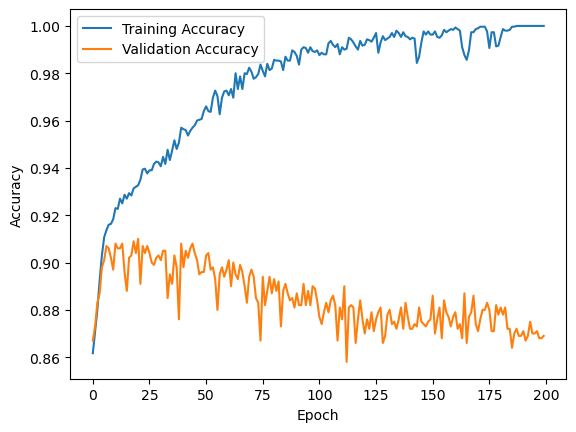

In [71]:
# Plot accuracy history

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

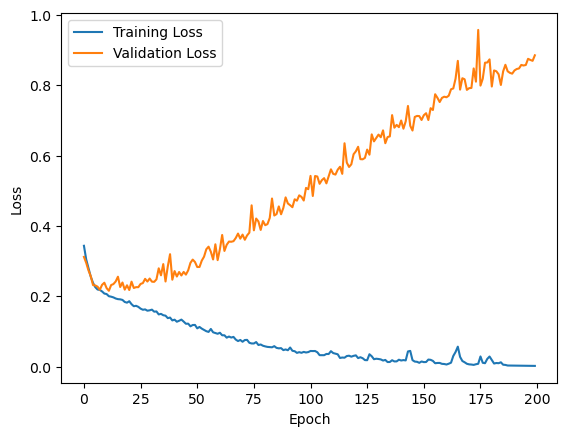

In [72]:
# Plot loss history

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Bias vs Variance

A model is:
* ***High bias*** if it is ***underfitting*** because it is *too simple* to capture the underlying complexity of the problem.
* ***High variance*** if it is ***overfitting*** because it is so complex it can memorize the training set.

With ***high bias*** models, the training and validation loss (or error) are ***both high***.

With ***high variance*** models, the ***training loss*** is ***low***, but the ***validation loss*** is ***high***.
![Bias-Variance-Tradeoff-In-Machine-Learning-1.png](https://www.learnopencv.com/wp-content/uploads/2017/02/Bias-Variance-Tradeoff-In-Machine-Learning-1.png)

From: https://www.learnopencv.com/bias-variance-tradeoff-in-machine-learning/ 

# Fighting overfitting

![fighting-overfitting](https://www.learnopencv.com/wp-content/uploads/2017/02/Machine-Learning-Workflow.png)

From: https://www.learnopencv.com/bias-variance-tradeoff-in-machine-learning/ 

## Reducing the network's size


> *With four parameters I can fit an elephant, and with five I can make him wiggle his trunk.*
>
> --John von Neumann (attributed)


The simplest way to prevent overfitting is to reduce the size of the model, i.e. the number of learnable parameters in the model (which is 
determined by the number of layers and the number of units per layer). In deep learning, the number of learnable parameters in a model is 
often referred to as the model's "capacity". Intuitively, a model with more parameters will have more "memorization capacity" and therefore 
will be able to easily learn a perfect dictionary-like mapping between training samples and their targets, a mapping without any 
generalization power. Always keep this in mind: *deep learning models tend to be good at fitting to the training data, but the real challenge 
is generalization, not fitting.*

# Weight regularization

## Adding weight regularization


Given some training data and a network architecture, there are multiple sets of weights values (multiple _models_) that could explain the data, and 
simpler models are less likely to overfit than complex ones.

A "simple model" in this context is a model where the distribution of parameter values has less entropy (or a model with fewer 
parameters altogether, as we saw in the section above). Thus a common way to mitigate overfitting is to put constraints on the complexity 
of a network by forcing its weights to only take small values, which makes the distribution of weight values more "regular". This is called 
"weight regularization", and it is done by adding to the loss function of the network a _cost_ associated with having large weights. This 
cost comes in two flavors:

* L1 regularization, where the cost added is proportional to the _absolute value of the weights coefficients_ (i.e. to what is called the 
"L1 norm" of the weights).
* L2 regularization, where the cost added is proportional to the _square of the value of the weights coefficients_ (i.e. to what is called 
the "L2 norm" of the weights). L2 regularization is also called _weight decay_ in the context of neural networks. Don't let the different 
name confuse you: weight decay is mathematically the exact same as L2 regularization.

In Keras, weight regularization is added by passing _weight regularizer instances_ to layers as keyword arguments. Let's add L2 weight 
regularization to our movie review classification network:

In [73]:
# Build the model with  L2 regularization
# Create model2 with the same configuration used in the previous model
# add a L2 regularization with alpha = 0.01 -> kernel_regularizer=tf.keras.regularizers.l2(0.01)

model2 = Sequential ([

     Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
     Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
     Dense(1, activation='sigmoid'),
])

print (model)

In [74]:
# Compile the model

# compile model2 wih the same parameters as before

model2.compile(optimizer='adam', 
              loss='binary_crossentropy',  
              metrics=['accuracy'])

In [75]:
# Train the model

# Train model2 with the same parameters as before and save in history2

history2 = model2.fit(X_train, y_train, epochs = 200, batch_size = 32, validation_data=(X_val, y_val))

Epoch 1/200
94/94 [==============================] - 1s 7ms/step - loss: 1.2410 - accuracy: 0.8560 - val_loss: 0.8188 - val_accuracy: 0.8640
Epoch 2/200
94/94 [==============================] - 0s 2ms/step - loss: 0.6380 - accuracy: 0.8660 - val_loss: 0.4970 - val_accuracy: 0.8690
Epoch 3/200
94/94 [==============================] - 0s 2ms/step - loss: 0.4449 - accuracy: 0.8703 - val_loss: 0.3940 - val_accuracy: 0.8780
Epoch 4/200
94/94 [==============================] - 0s 2ms/step - loss: 0.3796 - accuracy: 0.8720 - val_loss: 0.3578 - val_accuracy: 0.8800
Epoch 5/200
94/94 [==============================] - 0s 2ms/step - loss: 0.3557 - accuracy: 0.8780 - val_loss: 0.3413 - val_accuracy: 0.8780
Epoch 6/200
94/94 [==============================] - 0s 2ms/step - loss: 0.3469 - accuracy: 0.8780 - val_loss: 0.3316 - val_accuracy: 0.8830
Epoch 7/200
94/94 [==============================] - 0s 2ms/step - loss: 0.3394 - accuracy: 0.8797 - val_loss: 0.3282 - val_accuracy: 0.8820
Epoch 8/200
9

`l2(0.001)` means that every coefficient in the weight matrix of the layer will add `0.001 * weight_coefficient_value` to the total loss of 
the network. Note that because this penalty is _only added at training time_, the loss for this network will be much higher at training 
than at test time.

Here's the impact of our L2 regularization penalty:

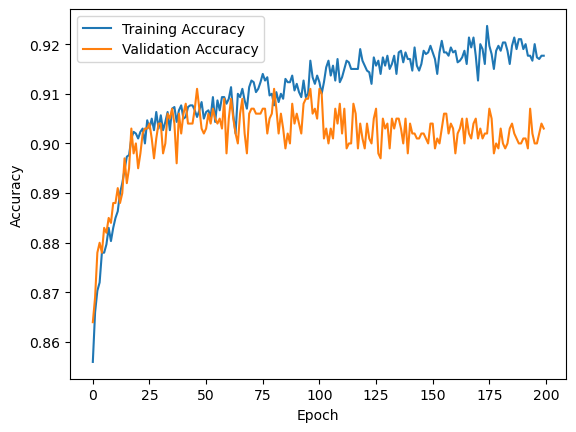

In [76]:
# Plot accuracy history

plt.plot(history2.history['accuracy'], label='Training Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

As you can see, the model with L2 regularization (dots) has become much more resistant to overfitting than the reference model (crosses), even though both models have the same number of parameters.

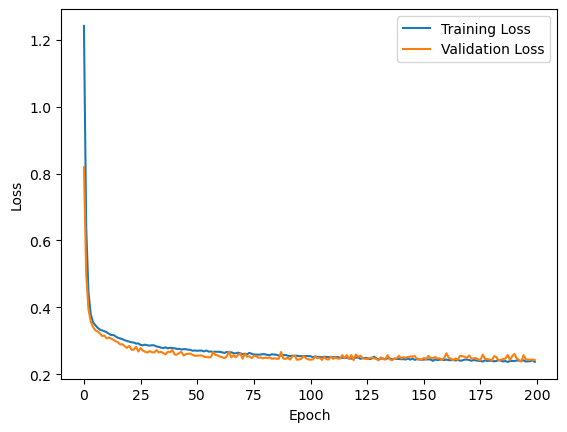

In [77]:
# Plot loss history

plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()